# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Raffaella Alpaca

**Date:** 9/9/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


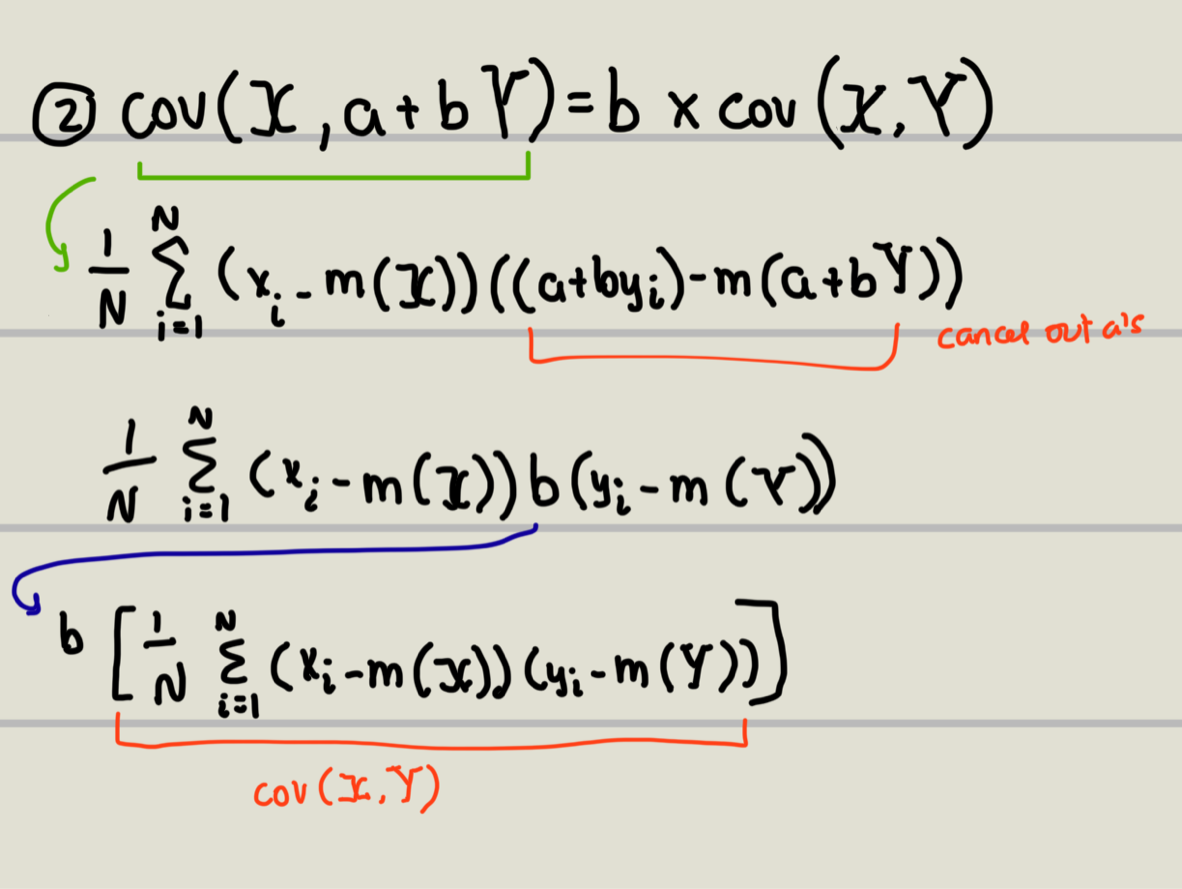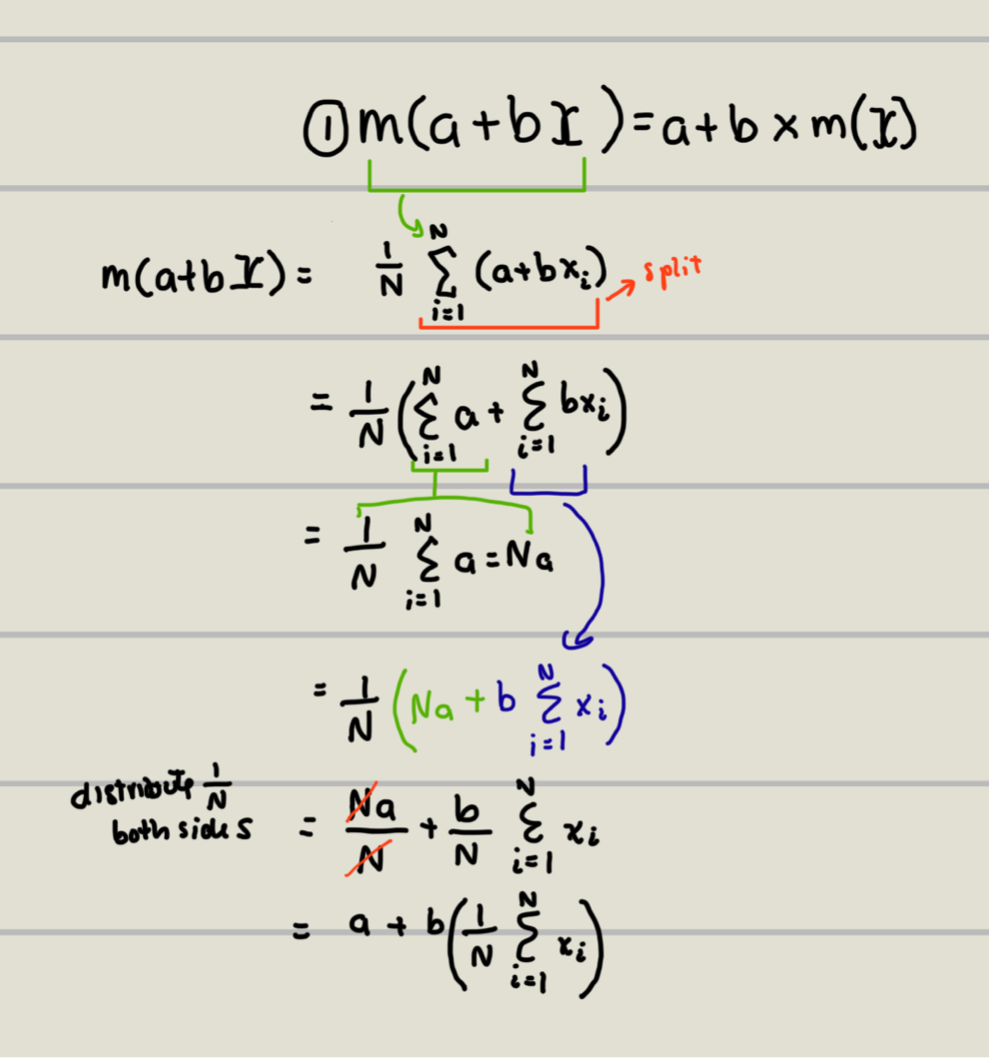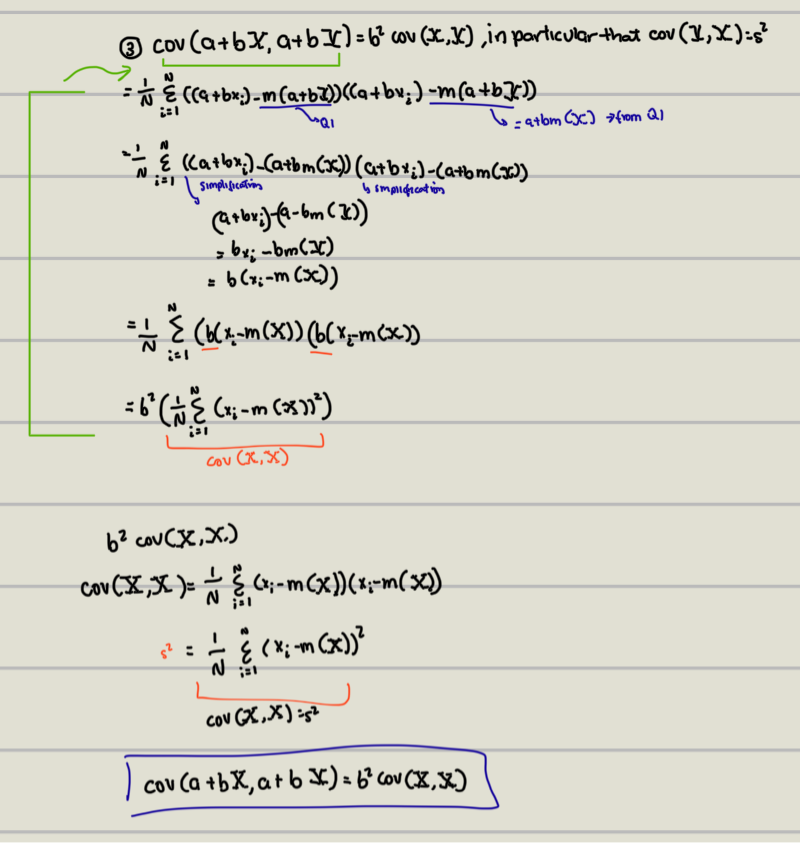

Q2

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("ForeignGifts_edu.csv")

In [11]:
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [ ]:
df.columns

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='object')

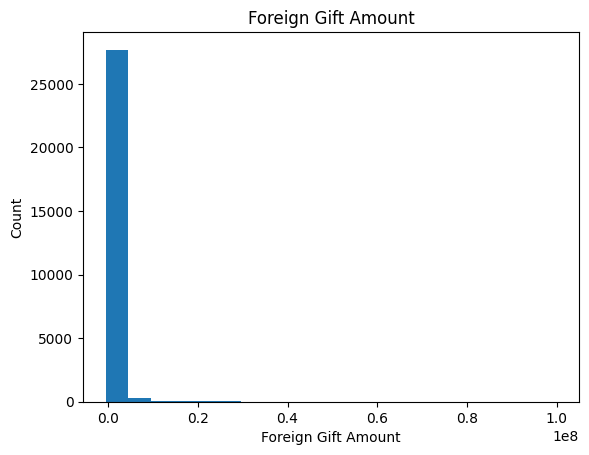

In [ ]:
df["Foreign Gift Amount"].hist(bins=20, grid=False)

plt.title("Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")

plt.show()

In [ ]:
df["Foreign Gift Amount"].describe()

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


The histogram shows that most foreign gift amounts are relatively small, while a few gifts are much larger. This makes the distribution stretched to the right. The large gift amounts also make the mean higher than the median.


**Q2. 3**

In [ ]:
df["Gift Type"].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [ ]:
df["Gift Type"].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [ ]:
#in percentages instead of decimals
df["Gift Type"].value_counts(normalize=True) * 100

,proportion
Gift Type,
Contract,61.209737
Monetary Gift,38.751285
Real Estate,0.038978


About 61.2% of the gifts are contracts, 38.8% are monetary gifts, and about 0.04% are real estate gifts. Contracts are the most common gift type, while real estate gifts are rare.

**Q2.4**

In [ ]:
df_positive = df[df["Foreign Gift Amount"] > 0].copy()

In [ ]:
#log column
df_positive["log_gift_amount"] = np.log(df_positive["Foreign Gift Amount"])

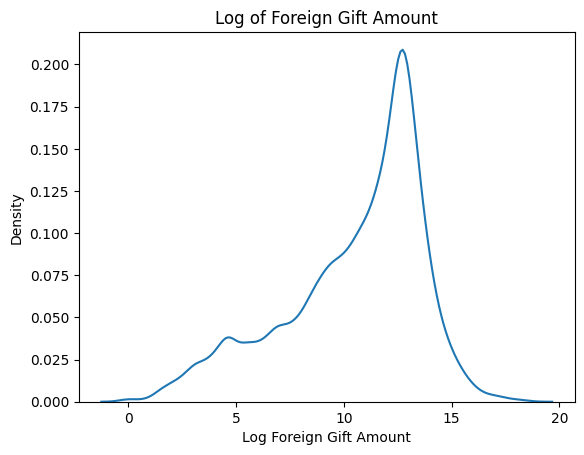

In [ ]:
sns.kdeplot(
    data=df_positive,
    x="log_gift_amount"
)
plt.title("Log of Foreign Gift Amount")
plt.xlabel("Log Foreign Gift Amount")
plt.show()

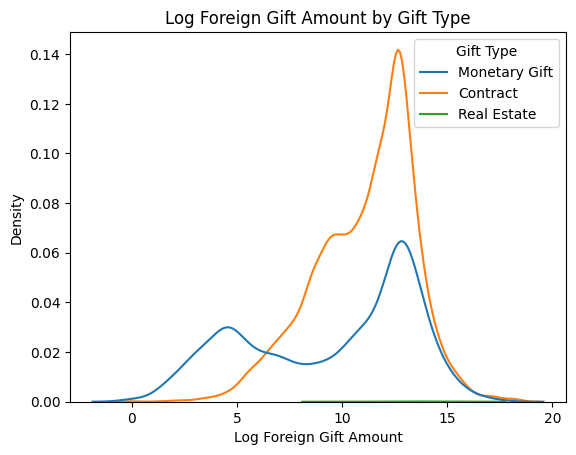

In [ ]:
sns.kdeplot(
    data=df_positive,
    x="log_gift_amount",
    hue="Gift Type"
)
plt.title("Log Foreign Gift Amount by Gift Type")
plt.xlabel("Log Foreign Gift Amount")
plt.show()

The log makes the distribution easier to see. Contracts and monetary gifts are both concentrated around higher log gift amounts, but monetary gifts are more spread out. Real estate gifts are very uncommon, so their line is very small.

**Q2.5**

In [12]:
#top 15 by number of gifts
#which countries appear the most times in the dataset
country_count = df.groupby("Country of Giftor").size()
country_count.sort_values(ascending=False).head(15)

,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [13]:
#top 15 by total amount given
country_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
country_amount.sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


England has the highest number of gifts, followed by China and Canada.But, Qatar gave the largest total amount of money, followed by England and China. This shows that the countries with the most gifts are not always the countries that give the most money overall.

**Q2.6**

In [14]:
#puts all rows together from the same giftor together
giftor_amount = df.groupby("Giftor Name")["Foreign Gift Amount"].sum() #add money from each giftor
giftor_amount.sort_values(ascending=False).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


Qatar foundation provides the most money in total, about $1.17 billion rounded. Right below Qatar foundation, there are Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous, and the Saudi Arabian Cultural Mission. What I notice is that several top giftors are realted to Qatar and Saudi Arabia

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 965e469


- **AI tool and model used:** ChatGpt

### *Prompts used

1. Review my Phase 1 solution for Q2 about the Foreign Gifts dataset. Identify any errors, unclear explanations, or improvements I should make
2. For each proposed change, explain why the change would improve my solution and whether it changes the result or only improves the explanation.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]